08번 웹캠 실시간 인식

In [1]:
# 08-1. 모델 불러오기
from ultralytics import YOLO

model = YOLO("../runs/detect/train-14/weights/best.pt")

print("학습된 YOLO 모델 불러오기 성공!")
print("클래스:", model.names)

학습된 YOLO 모델 불러오기 성공!
클래스: {0: 'nipper', 1: 'pen', 2: 'wire_stripper'}


In [6]:
import cv2

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("❌ 카메라를 열 수 없습니다.")
else:
    print("📷 카메라 시작!")
    print("Q를 누르면 종료합니다.")

    while True:
        ret, frame = cap.read()

        if not ret:
            print("❌ 카메라 프레임을 읽을 수 없습니다.")
            break

        # YOLO 예측
        results = model.predict(
            source=frame,
            imgsz=640,
            conf=0.25,       
            device="cpu",
            verbose=False
        )

        result = results[0]

        # 검출 결과를 터미널에 출력
        if len(result.boxes) > 0:

            print("----- 검출 결과 -----")

            for box in result.boxes:
                class_id = int(box.cls[0])
                confidence = float(box.conf[0])

                class_name = model.names[class_id]

                print(
                    f"{class_name:15s} "
                    f"confidence = {confidence:.3f}"
                )

        else:
            print("검출된 물체 없음")

        # 화면에 Bounding Box 표시
        annotated_frame = result.plot()

        cv2.imshow(
            "YOLO Object Detection",
            annotated_frame
        )

        # Q 종료
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()

📷 카메라 시작!
Q를 누르면 종료합니다.
----- 검출 결과 -----
pen             confidence = 0.428
----- 검출 결과 -----
pen             confidence = 0.401
----- 검출 결과 -----
pen             confidence = 0.412
----- 검출 결과 -----
pen             confidence = 0.398
----- 검출 결과 -----
pen             confidence = 0.421
pen             confidence = 0.260
----- 검출 결과 -----
pen             confidence = 0.396
----- 검출 결과 -----
pen             confidence = 0.393
----- 검출 결과 -----
pen             confidence = 0.351
----- 검출 결과 -----
pen             confidence = 0.351
----- 검출 결과 -----
pen             confidence = 0.336
----- 검출 결과 -----
pen             confidence = 0.264
----- 검출 결과 -----
pen             confidence = 0.273
검출된 물체 없음
----- 검출 결과 -----
pen             confidence = 0.268
----- 검출 결과 -----
pen             confidence = 0.282
----- 검출 결과 -----
pen             confidence = 0.265
검출된 물체 없음
----- 검출 결과 -----
pen             confidence = 0.260
----- 검출 결과 -----
pen             confidence = 0.282
검출된 물체 없음
----- 검출 결

train-15/best.pt가 이번에 yolo_dataset_v2로 새로 학습한 모델.
train-14는 이전 모델이니까 이번 테스트에서는 train-15를 사용하여 테스트.

In [ ]:
# 1️⃣ YOLO 모델 + 카메라 실행

In [8]:
import cv2
from ultralytics import YOLO

# 이번에 새로 학습한 모델
model = YOLO(
    "../runs/detect/train-15/weights/best.pt"
)

# 웹캠 열기
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("❌ 카메라를 열 수 없습니다.")
    raise SystemExit

print("카메라 실행 중")
print("종료하려면 Q를 누르세요.")

while True:

    ret, frame = cap.read()

    if not ret:
        print("❌ 카메라 프레임을 읽을 수 없습니다.")
        break

    # YOLO 실시간 탐지
    results = model.predict(
        source=frame,
        imgsz=640,
        conf=0.5,
        device="cpu",
        verbose=False
    )

    # 탐지 결과를 화면에 그리기
    annotated_frame = results[0].plot()

    cv2.imshow("YOLO Object Detection", annotated_frame)

    # Q를 누르면 종료
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

카메라 실행 중
종료하려면 Q를 누르세요.


1. 웹캠에서 니퍼 사진 저장

In [1]:
import cv2

cap = cv2.VideoCapture(0)

print("니퍼를 카메라에 보여주세요.")
print("S = 사진 저장")
print("Q = 종료")

while True:
    ret, frame = cap.read()

    if not ret:
        break

    cv2.imshow("Nipper Test - Press S", frame)

    key = cv2.waitKey(1) & 0xFF

    if key == ord("s"):
        save_path = "../nipper_camera_test.jpg"
        cv2.imwrite(save_path, frame)
        print(f"사진 저장 완료: {save_path}")

    elif key == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

니퍼를 카메라에 보여주세요.
S = 사진 저장
Q = 종료


QFontDatabase: Cannot find font directory /home/user14/Documents/GitHub/DeepLearningProject/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/user14/Documents/GitHub/DeepLearningProject/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/user14/Documents/GitHub/DeepLearningProject/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/user14/Documents/GitHub/DeepLearningProject/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://de

사진 저장 완료: ../nipper_camera_test.jpg
사진 저장 완료: ../nipper_camera_test.jpg
사진 저장 완료: ../nipper_camera_test.jpg


In [ ]:
2. 저장한 사진을 새 모델로만 테스트

In [2]:
from ultralytics import YOLO

model = YOLO(
    "../runs/detect/train-15/weights/best.pt"
)

results = model.predict(
    source="../nipper_camera_test.jpg",
    imgsz=640,
    conf=0.01,
    device="cpu",
    save=True,
    verbose=False
)

print("탐지 결과")

Results saved to /home/user14/Documents/GitHub/DeepLearningProject/runs/detect/predict
탐지 결과


In [ ]:
웹캠에서 니퍼 사진 하나를 저장해서 실제 모델이 어떻게 예측하는지 확인

3. 모델이 실제로 뭐라고 생각하는지 출력

In [3]:
result = results[0]

print("탐지 개수:", len(result.boxes))

for box in result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    print(
        f"클래스: {class_id} "
        f"({model.names[class_id]}) "
        f"확률: {confidence:.3f}"
    )

탐지 개수: 5
클래스: 1 (pen) 확률: 0.598
클래스: 1 (pen) 확률: 0.108
클래스: 1 (pen) 확률: 0.075
클래스: 1 (pen) 확률: 0.025
클래스: 1 (pen) 확률: 0.023


웹캠에서 SPACE를 누르면 니퍼 사진을 자동 저장하고, 나중에 한 번에 라벨을 생성하는 방식을 새로 입력

In [4]:
# 1️⃣ 니퍼 사진 자동 수집

import cv2
from pathlib import Path

# 저장 폴더
save_dir = Path("../dataset/nipper_camera")
save_dir.mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("❌ 카메라를 열 수 없습니다.")
    raise SystemExit

count = len(list(save_dir.glob("*.jpg")))

print("=== 니퍼 데이터 수집 ===")
print("SPACE : 사진 저장")
print("Q     : 종료")
print(f"현재 사진 수: {count}")

while True:

    ret, frame = cap.read()

    if not ret:
        print("❌ 카메라 프레임을 읽을 수 없습니다.")
        break

    # 화면에 현재 개수 표시
    display = frame.copy()

    cv2.putText(
        display,
        f"Nipper images: {count}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    cv2.putText(
        display,
        "SPACE: Save / Q: Quit",
        (20, 80),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2
    )

    cv2.imshow("Nipper Data Collection", display)

    key = cv2.waitKey(1) & 0xFF

    # SPACE
    if key == 32:

        filename = save_dir / f"nipper_camera_{count:04d}.jpg"

        cv2.imwrite(str(filename), frame)

        count += 1

        print(f"저장: {filename}")

    # Q
    elif key == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

print(f"\n총 {count}장 저장 완료")

=== 니퍼 데이터 수집 ===
SPACE : 사진 저장
Q     : 종료
현재 사진 수: 0
저장: ../dataset/nipper_camera/nipper_camera_0000.jpg
저장: ../dataset/nipper_camera/nipper_camera_0001.jpg
저장: ../dataset/nipper_camera/nipper_camera_0002.jpg
저장: ../dataset/nipper_camera/nipper_camera_0003.jpg
저장: ../dataset/nipper_camera/nipper_camera_0004.jpg
저장: ../dataset/nipper_camera/nipper_camera_0005.jpg
저장: ../dataset/nipper_camera/nipper_camera_0006.jpg
저장: ../dataset/nipper_camera/nipper_camera_0007.jpg
저장: ../dataset/nipper_camera/nipper_camera_0008.jpg
저장: ../dataset/nipper_camera/nipper_camera_0009.jpg
저장: ../dataset/nipper_camera/nipper_camera_0010.jpg
저장: ../dataset/nipper_camera/nipper_camera_0011.jpg
저장: ../dataset/nipper_camera/nipper_camera_0012.jpg
저장: ../dataset/nipper_camera/nipper_camera_0013.jpg
저장: ../dataset/nipper_camera/nipper_camera_0014.jpg
저장: ../dataset/nipper_camera/nipper_camera_0015.jpg
저장: ../dataset/nipper_camera/nipper_camera_0016.jpg
저장: ../dataset/nipper_camera/nipper_camera_0017.jpg
저장: ../dat

사진을 찍은 폴더가 ../dataset/nipper_camera/에 제대로 만들어졌는지 먼저 확인

In [5]:
from pathlib import Path

save_dir = Path("../dataset/nipper_camera")

images = list(save_dir.glob("*.jpg"))

print("니퍼 웹캠 사진:", len(images), "장")

for image in images[:10]:
    print(image.name)
    

니퍼 웹캠 사진: 64 장
nipper_camera_0045.jpg
nipper_camera_0030.jpg
nipper_camera_0016.jpg
nipper_camera_0050.jpg
nipper_camera_0011.jpg
nipper_camera_0031.jpg
nipper_camera_0040.jpg
nipper_camera_0002.jpg
nipper_camera_0056.jpg
nipper_camera_0001.jpg


캠으로 찍은 니퍼 50장에 정확한 nipper(0) 박스를 만드는 단계

총 이미지: 64


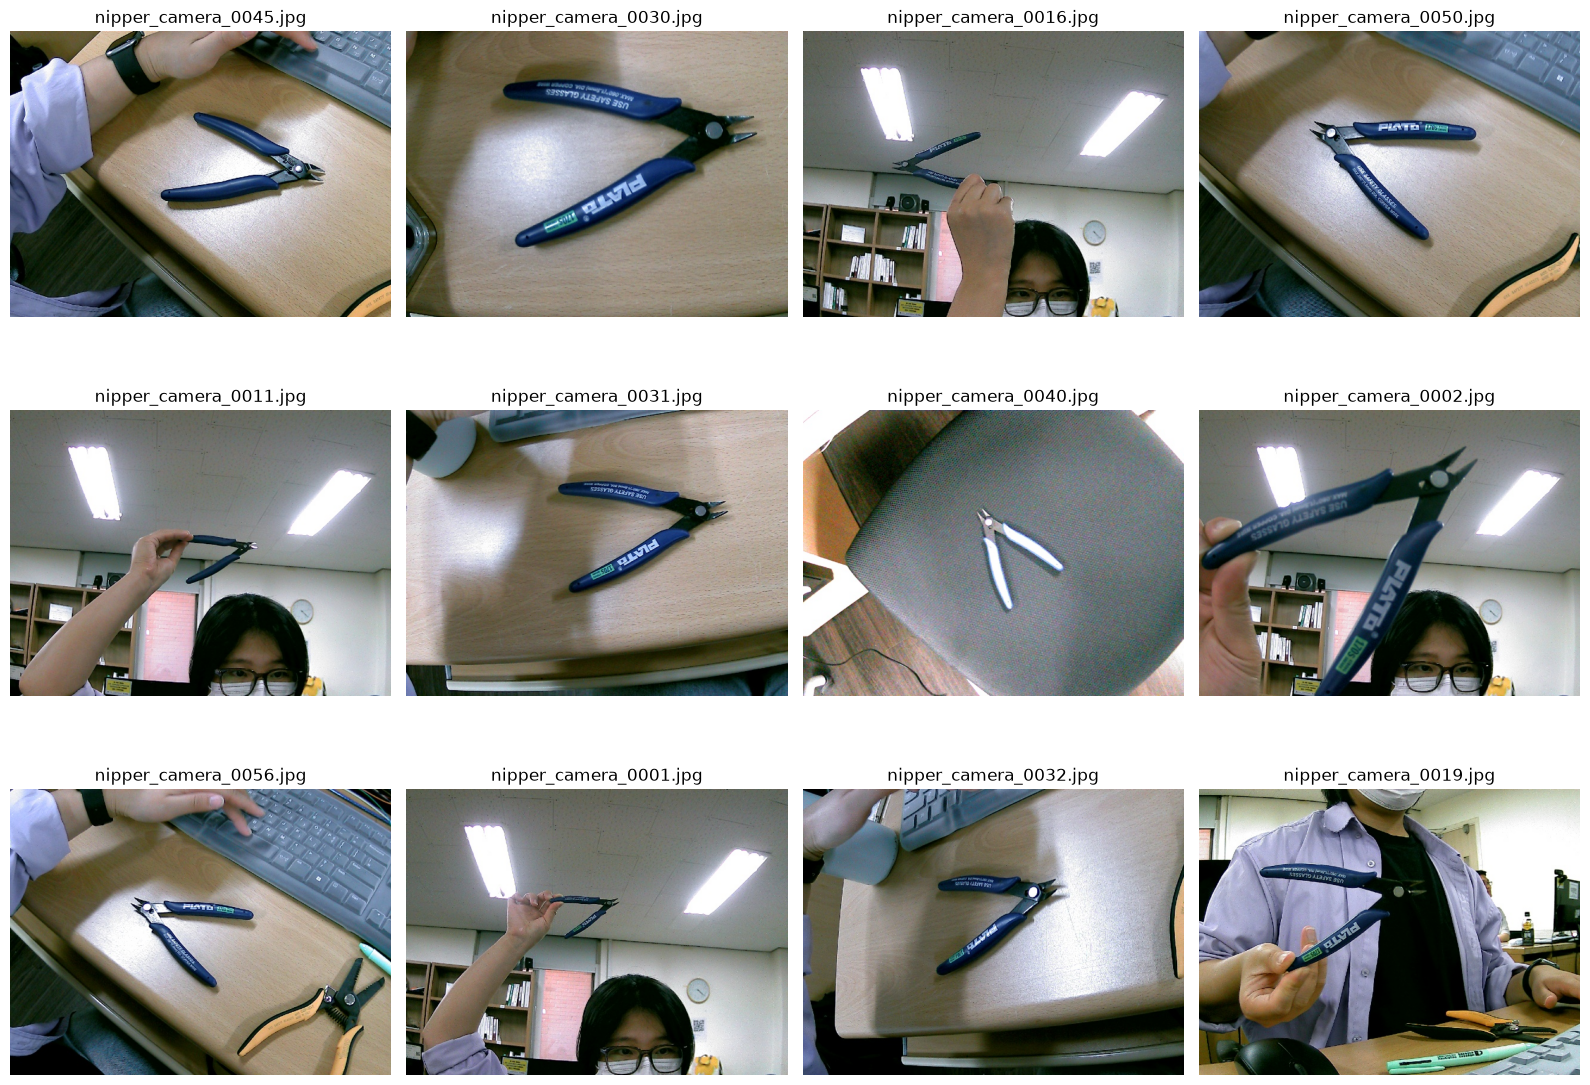

In [6]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# 웹캠으로 찍은 니퍼 사진
image_dir = Path("../dataset/nipper_camera")

images = list(image_dir.glob("*.jpg"))

print("총 이미지:", len(images))

# 최대 12장 확인
images = images[:12]

plt.figure(figsize=(16, 12))

for i, image_path in enumerate(images):

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(image_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
import cv2
from pathlib import Path

# 니퍼 웹캠 사진
image_dir = Path("../dataset/nipper_camera")

# YOLO 라벨 저장 위치
label_dir = Path("../dataset/nipper_camera_labels")
label_dir.mkdir(parents=True, exist_ok=True)

images = sorted(image_dir.glob("*.jpg"))

print("총 이미지:", len(images))
print("라벨 저장 위치:", label_dir)

for i, image_path in enumerate(images):
    image = cv2.imread(str(image_path))

    if image is None:
        print("이미지를 읽을 수 없음:", image_path)
        continue

    h, w = image.shape[:2]

    # 바운딩 박스 선택
    print(f"\n[{i+1}/{len(images)}] {image_path.name}")
    print("니퍼 전체를 드래그한 뒤 Enter를 누르세요.")
    
    x, y, box_w, box_h = cv2.selectROI(
        "Nipper Labeling",
        image,
        fromCenter=False,
        showCrosshair=True
    )

    # 선택 취소
    if box_w == 0 or box_h == 0:
        print("건너뜀:", image_path.name)
        continue

    # YOLO 형식으로 변환
    x_center = (x + box_w / 2) / w
    y_center = (y + box_h / 2) / h
    width = box_w / w
    height = box_h / h

    # class 0 = nipper
    label_text = f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n"

    label_path = label_dir / f"{image_path.stem}.txt"

    with open(label_path, "w") as f:
        f.write(label_text)

    print("저장:", label_path.name)

cv2.destroyAllWindows()

print("\n라벨링 완료!")

총 이미지: 64
라벨 저장 위치: ../dataset/nipper_camera_labels

[1/64] nipper_camera_0000.jpg
니퍼 전체를 드래그한 뒤 Enter를 누르세요.
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
저장: nipper_camera_0000.txt

[2/64] nipper_camera_0001.jpg
니퍼 전체를 드래그한 뒤 Enter를 누르세요.
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
저장: nipper_camera_0001.txt

[3/64] nipper_camera_0002.jpg
니퍼 전체를 드래그한 뒤 Enter를 누르세요.
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
저장: nipper_camera_0002.txt

[4/64] nipper_camera_0003.jpg
니퍼 전체를 드래그한 뒤 Enter를 누르세요.
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
저장: nipper_camera_0003.txt

[5/64] nipper_camera_0004.jpg
니퍼 전체를 드래그한 뒤 Enter를 누르세요.
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
저장: nipper_camera_0004.txt

[6/64] nippe

좋아. 👍 이제 수동으로 만든 니퍼 라벨이 제대로 저장됐는지 확인하고, 문제가 없으면 yolo_dataset_v2에 추가하자.


1단계 — 라벨 개수 확인

In [8]:
from pathlib import Path

image_dir = Path("../dataset/nipper_camera")
label_dir = Path("../dataset/nipper_camera_labels")

images = sorted(image_dir.glob("*.jpg"))
labels = sorted(label_dir.glob("*.txt"))

print("니퍼 이미지:", len(images), "장")
print("니퍼 라벨:", len(labels), "개")

# 라벨이 없는 이미지 확인
image_names = {p.stem for p in images}
label_names = {p.stem for p in labels}

missing = image_names - label_names

print("라벨 없는 이미지:", len(missing))

if missing:
    print("라벨 없는 파일:")
    for name in sorted(missing):
        print(name)
else:
    print("✅ 모든 이미지에 라벨이 있습니다.")

니퍼 이미지: 64 장
니퍼 라벨: 64 개
라벨 없는 이미지: 0
✅ 모든 이미지에 라벨이 있습니다.


2단계 — 라벨 내용도 확인

In [9]:
for label_path in sorted(label_dir.glob("*.txt"))[:10]:
    print("\n", label_path.name)
    
    with open(label_path, "r") as f:
        print(f.read().strip())


 nipper_camera_0000.txt
0 0.463281 0.542708 0.801562 0.810417

 nipper_camera_0001.txt
0 0.465625 0.439583 0.206250 0.208333

 nipper_camera_0002.txt
0 0.404687 0.540625 0.681250 0.918750

 nipper_camera_0003.txt
0 0.514844 0.480208 0.876563 0.810417

 nipper_camera_0004.txt
0 0.626563 0.485417 0.525000 0.566667

 nipper_camera_0005.txt
0 0.423438 0.485417 0.631250 0.650000

 nipper_camera_0006.txt
0 0.531250 0.485417 0.340625 0.733333

 nipper_camera_0007.txt
0 0.568750 0.456250 0.328125 0.654167

 nipper_camera_0008.txt
0 0.554688 0.506250 0.459375 0.591667

 nipper_camera_0009.txt
0 0.623437 0.479167 0.606250 0.575000


3단계 — 문제 없으면 다음 단계

0 = nipper
1 = pen
2 = wire_stripper

전부 0으로 Nipper로 인식해야 성공 

확인이 끝나면 이 50장 정도의 실제 웹캠 니퍼 데이터 + 정확한 수동 라벨을 기존 yolo_dataset_v2 에 추가해서 새로운 데이터셋을 만들기.

3단계 — 웹캠 니퍼 데이터를 v3에 추가

In [10]:
from pathlib import Path
import shutil
import random

project = Path("/home/user14/Documents/GitHub/DeepLearningProject")

# 기존 데이터셋
old_dataset = project / "yolo_dataset_v2"

# 새 데이터셋
new_dataset = project / "yolo_dataset_v3"

# 웹캠 니퍼 데이터
camera_images = project / "dataset/nipper_camera"
camera_labels = project / "dataset/nipper_camera_labels"

# 기존 v2를 그대로 복사
if not new_dataset.exists():
    shutil.copytree(old_dataset, new_dataset)
    print("yolo_dataset_v2 → yolo_dataset_v3 복사 완료")
else:
    print("yolo_dataset_v3가 이미 존재합니다.")

# 이미지 목록
images = sorted(camera_images.glob("*.jpg"))

print("웹캠 니퍼 이미지:", len(images))

# 랜덤하게 섞기
random.seed(42)
random.shuffle(images)

# 45장 train
# 10장 val
# 9장 test
train_images = images[:45]
val_images = images[45:55]
test_images = images[55:64]

splits = {
    "train": train_images,
    "val": val_images,
    "test": test_images
}

# 복사
for split, split_images in splits.items():

    image_dst = new_dataset / "images" / split
    label_dst = new_dataset / "labels" / split

    image_dst.mkdir(parents=True, exist_ok=True)
    label_dst.mkdir(parents=True, exist_ok=True)

    for image_path in split_images:

        label_path = camera_labels / f"{image_path.stem}.txt"

        if not label_path.exists():
            print("⚠️ 라벨 없음:", image_path.name)
            continue

        shutil.copy2(
            image_path,
            image_dst / image_path.name
        )

        shutil.copy2(
            label_path,
            label_dst / label_path.name
        )

    print(f"{split}: {len(split_images)}장 추가")

print("\n✅ yolo_dataset_v3 생성 완료")

yolo_dataset_v2 → yolo_dataset_v3 복사 완료
웹캠 니퍼 이미지: 64
train: 45장 추가
val: 10장 추가
test: 9장 추가

✅ yolo_dataset_v3 생성 완료


4단계 — 데이터 개수 확인

In [11]:
from pathlib import Path

dataset = Path("../yolo_dataset_v3")

for split in ["train", "val", "test"]:

    images = list((dataset / "images" / split).glob("*.jpg"))
    labels = list((dataset / "labels" / split).glob("*.txt"))

    print(
        f"{split:5s} → "
        f"이미지 {len(images):4d}장 / "
        f"라벨 {len(labels):4d}개"
    )

train → 이미지 1252장 / 라벨 1252개
val   → 이미지  316장 / 라벨  316개
test  → 이미지  184장 / 라벨  184개


5단계 — YOLO train-16 학습

In [12]:
from ultralytics import YOLO

# YOLO 모델
model = YOLO("yolo11n.pt")

# 학습
results = model.train(
    data="../yolo_dataset_v3/data.yaml",
    epochs=10,
    imgsz=640,
    batch=2,
    device="cpu"
)

print("YOLO train-16 학습 완료!")

Ultralytics 8.4.150 🚀 Python-3.12.3 torch-2.14.0+cu130 CPU (Intel Core i5-10400F 2.90GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../yolo_dataset_v3/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-16, nbs=64, nms=None, opset=None, 

/home/user14/Documents/GitHub/DeepLearningProject/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:484: UserWarning: Found GPU0 NVIDIA GeForce GT 1030 which is of compute capability (CC) 6.1.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 12.0 which supports hardware CC >=12.0,<13.0
Your installed torch==2.14.0+cu130 does not include kernels for this GPU. Reinstall the same version against a CUDA build that does, e.g.:
  For CUDA 12.6 use pip install torch==2.14.0 --index-url https://download.pytorch.org/whl/cu126
  _warn_unsupported_code(d, device_cc, code_ccs)
/home/user14/Documents/GitHub/DeepLearningProject/.venv/lib/python3.12/site-packages/torch/cuda/__

       1/10         0G      1.409      3.794      1.652          1        640: 100% ━━━━━━━━━━━━ 604/604 1.9it/s 5:250.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 77/77 2.4it/s 32.7s0.4ss
                   all        306        455      0.496      0.355      0.328      0.174

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/10         0G      1.622       3.34      1.829          1        640: 100% ━━━━━━━━━━━━ 604/604 1.9it/s 5:260.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 77/77 2.3it/s 33.1s0.4ss
                   all        306        455      0.631      0.412      0.493      0.298

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/10         0G      1.624      2.818      1.838          1        640: 100% ━━━━━━━━━━━━ 604/604 1.9it/s 5:260.4ss
                 Class     Im

6단계 — train-16 성능 평가

In [13]:
from ultralytics import YOLO

# train-16에서 가장 성능이 좋았던 모델 불러오기
model = YOLO("../runs/detect/train-16/weights/best.pt")

# 테스트 데이터 평가
metrics = model.val(
    data="../yolo_dataset_v3/data.yaml",
    split="test",
    imgsz=640,
    device="cpu"
)

print("평가 완료!")

Ultralytics 8.4.150 🚀 Python-3.12.3 torch-2.14.0+cu130 CPU (Intel Core i5-10400F 2.90GHz)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2429.4±936.2 MB/s, size: 75.9 KB)
val: Scanning /home/user14/Documents/GitHub/DeepLearningProject/yolo_dataset_v2/labels/test.cache... 175 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 175/175 61.2Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 12, len(boxes) = 228. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 1.1it/s 10.0s.9s
                   all        175        228      0.834      0.739      0.811      0.634
                nipper         44         44      0.774          1      

카메라 테스트 실행

In [8]:
import cv2
from ultralytics import YOLO

# 학습된 YOLO 모델 불러오기
model = YOLO("../runs/detect/train-16/weights/best.pt")

# 웹캠 열기
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("카메라를 열 수 없습니다.")
    exit()

print("카메라 테스트 시작")
print("종료하려면 Q 키를 누르세요.")

while True:
    ret, frame = cap.read()

    if not ret:
        print("카메라에서 영상을 가져올 수 없습니다.")
        break

    # YOLO로 실시간 객체 탐지
    results = model.predict(
        source=frame,
        imgsz=640,
        conf=0.5,
        device="cpu",
        verbose=False
    )

    # 탐지 결과를 화면에 표시
    annotated_frame = results[0].plot()

    # 카메라 화면 출력
    cv2.imshow("YOLO Real-Time Detection", annotated_frame)

    # Q를 누르면 종료
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

카메라 테스트 시작
종료하려면 Q 키를 누르세요.


## 카메라 인식 테스트


In [9]:
import cv2
from ultralytics import YOLO
import random
import time


# ==================================================
# 1. 학습한 YOLO 모델 불러오기
# ==================================================

model = YOLO("../runs/detect/train-16/weights/best.pt")


# ==================================================
# 2. YOLO 클래스 확인
# ==================================================

# 학습된 모델이 알고 있는 물건
classes = list(model.names.values())

print()
print("================================")
print("       YOLO 물건 찾기 게임")
print("================================")
print()

print("AI가 알고 있는 물건:")
print(classes)
print()


# ==================================================
# 3. 게임 설정
# ==================================================

# YOLO가 정답이라고 인정할 최소 confidence
confidence_threshold = 0.50

# 몇 번 연속 정답이면 성공할 것인지
required_count = 3

# 현재 정답 연속 횟수
correct_count = 0

# 지금까지 찾은 물건
completed_objects = []


# ==================================================
# 4. 랜덤으로 첫 번째 목표물 선택
# ==================================================

remaining_objects = classes.copy()

target = random.choice(remaining_objects)

print("================================")
print("🎯 찾아야 하는 물건")
print(f"👉 {target}")
print("================================")
print()


# ==================================================
# 5. 웹캠 실행
# ==================================================

camera = cv2.VideoCapture(0)

if not camera.isOpened():

    print("❌ 웹캠을 열 수 없습니다.")
    raise SystemExit

print("✅ 웹캠이 시작되었습니다.")
print("Q 키를 누르면 게임을 종료합니다.")
print()


# ==================================================
# 6. 게임 시작
# ==================================================

while True:

    # --------------------------------------------------
    # 카메라에서 프레임 가져오기
    # --------------------------------------------------

    ret, frame = camera.read()

    if not ret:

        print("❌ 웹캠 화면을 읽을 수 없습니다.")
        break


    # --------------------------------------------------
    # YOLO 객체 탐지
    # --------------------------------------------------

    results = model.predict(
        source=frame,

        # CPU 사용
        device="cpu",

        # 너무 크면 느리기 때문에 640 유지
        imgsz=640,

        # confidence
        conf=confidence_threshold,

        verbose=False
    )


    # --------------------------------------------------
    # 첫 번째 결과 가져오기
    # --------------------------------------------------

    result = results[0]


    # --------------------------------------------------
    # 탐지된 물체 확인
    # --------------------------------------------------

    detected_target = False

    best_label = "없음"
    best_confidence = 0.0


    if result.boxes is not None and len(result.boxes) > 0:

        # 탐지된 모든 물체 확인
        for box in result.boxes:

            # 클래스 번호
            class_id = int(box.cls[0])

            # 클래스 이름
            label = model.names[class_id]

            # confidence
            confidence = float(box.conf[0])


            # 가장 높은 confidence 저장
            if confidence > best_confidence:

                best_confidence = confidence
                best_label = label


            # --------------------------------------------------
            # 현재 목표물인지 확인
            # --------------------------------------------------

            if label == target and confidence >= confidence_threshold:

                detected_target = True


    # ==================================================
    # 정답 판정
    # ==================================================

    if detected_target:

        correct_count += 1

    else:

        correct_count = 0


    # ==================================================
    # YOLO 탐지 결과 화면에 표시
    # ==================================================

    annotated_frame = result.plot()


    # ==================================================
    # 게임 UI
    # ==================================================

    # 제목
    cv2.putText(
        annotated_frame,
        "OBJECT FIND GAME",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (255, 255, 255),
        2
    )


    # 현재 목표
    cv2.putText(
        annotated_frame,
        f"TARGET: {target}",
        (20, 80),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (0, 255, 255),
        2
    )


    # AI가 가장 확실하게 판단한 물체
    cv2.putText(
        annotated_frame,
        f"AI: {best_label}",
        (20, 120),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )


    # confidence
    cv2.putText(
        annotated_frame,
        f"Confidence: {best_confidence * 100:.1f}%",
        (20, 160),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )


    # 정답 진행률
    cv2.putText(
        annotated_frame,
        f"CORRECT: {correct_count}/{required_count}",
        (20, 200),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )


    # 남은 물건
    cv2.putText(
        annotated_frame,
        f"REMAINING: {len(remaining_objects)}",
        (20, 240),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )


    # ==================================================
    # 정답!
    # ==================================================

    if correct_count >= required_count:

        # 현재 물건 완료
        completed_objects.append(target)

        # 남은 목록에서 제거
        remaining_objects.remove(target)


        # --------------------------------------------------
        # 성공 메시지
        # --------------------------------------------------

        cv2.putText(
            annotated_frame,
            "CORRECT!",
            (100, 320),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.5,
            (0, 255, 0),
            4
        )


        cv2.imshow(
            "Object Game",
            annotated_frame
        )


        # 1.5초 동안 성공 화면
        cv2.waitKey(1500)


        print()
        print("🎉 정답!")
        print(f"찾은 물건 : {target}")
        print()


        # --------------------------------------------------
        # 모든 물건을 찾았는지 확인
        # --------------------------------------------------

        if len(remaining_objects) == 0:

            print("================================")
            print("       🎉 게임 클리어! 🎉")
            print("================================")
            print()

            print("찾은 물건:")
            print(completed_objects)

            break


        # --------------------------------------------------
        # 다음 목표물 선택
        # --------------------------------------------------

        target = random.choice(remaining_objects)

        correct_count = 0


        print("================================")
        print("🎯 다음 물건:")
        print(f"👉 {target}")
        print("================================")


        continue


    # ==================================================
    # 게임 화면 출력
    # ==================================================

    cv2.imshow(
        "Object Game",
        annotated_frame
    )


    # ==================================================
    # Q 키로 종료
    # ==================================================

    if cv2.waitKey(1) & 0xFF == ord("q"):

        print()
        print("게임을 종료했습니다.")

        break


# ==================================================
# 7. 웹캠 종료
# ==================================================

camera.release()

cv2.destroyAllWindows()

print()
print("웹캠 종료")


       YOLO 물건 찾기 게임

AI가 알고 있는 물건:
['nipper', 'pen', 'wire_stripper']

🎯 찾아야 하는 물건
👉 pen

✅ 웹캠이 시작되었습니다.
Q 키를 누르면 게임을 종료합니다.


🎉 정답!
찾은 물건 : pen

🎯 다음 물건:
👉 nipper

🎉 정답!
찾은 물건 : nipper

🎯 다음 물건:
👉 wire_stripper

🎉 정답!
찾은 물건 : wire_stripper

       🎉 게임 클리어! 🎉

찾은 물건:
['pen', 'nipper', 'wire_stripper']

웹캠 종료
